# 03 — Replicator Dynamics on the 2-simplex

**Inputs:** `../data/cleaned_responses.csv` (for empirical overlay)  
**Outputs:** `../figures/simplex_w*.png`, `../figures/simplex_panel.png`, `../figures/empirical_simplex.png`, `../data/stability_table.csv`.

Implements the discrete three-type EGT model from `EGT_Project.pdf` §*Discrete Three-Type Model*:

- Types: **A** (purists, $s_A = 0.1$), **B** (balancers, $s_B = 0.35$), **C** (strategists, $s_C = 0.7$)
- Population state $x = (x_A, x_B, x_C)$ on $\Delta^2$ with $\sum x_i = 1$
- Mean layup ratio: $\bar s = x_A s_A + x_B s_B + x_C s_C$
- Payoff: $\pi_i(x, w) = s_i (w - \gamma \bar s - \varepsilon) + \varepsilon$
- Replicator ODE: $\dot x_i = x_i (\pi_i - \bar\pi)$ with $\bar\pi = \sum_i x_i \pi_i$
- Continuous-strategy ESS: $s^\ast = (w - \varepsilon)/\gamma$, requiring $0 < w - \varepsilon < \gamma$ for an interior solution.

Stability of each vertex is assessed via the **analytical invasion fitness** of a rare mutant — eigenvalues of the linearized replicator on the simplex tangent space:
$\lambda_{i \to j} = (s_j - s_i)(w - \gamma s_i - \varepsilon)$ for $j \ne i$ at vertex $i$. This gives the two non-trivial eigenvalues directly, without a spurious off-simplex direction.

We integrate the replicator ODE forward from a grid of initial conditions and plot phase portraits at $w \in \{1, 3, 5\}$ — corresponding to undecided / tech-finance / pre-med tracks.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

FIGDIR = "../figures"
DATA = "../data/cleaned_responses.csv"

# Model parameters (from paper §Discrete Three-Type Model)
S_A, S_B, S_C = 0.1, 0.35, 0.7
S_VEC = np.array([S_A, S_B, S_C])
EPS = 0.5     # baseline value of a non-layup course
GAMMA = 3.0   # competition intensity; chosen so 0 < w-ε < γ for w ∈ (0.5, 3.5)

print(f"s_A={S_A}, s_B={S_B}, s_C={S_C}")
print(f"ε={EPS}, γ={GAMMA}")
print(f"Interior fixed point exists when s_A < (w-ε)/γ < s_C")
print(f"  → {EPS + GAMMA*S_A:.2f} < w < {EPS + GAMMA*S_C:.2f}, i.e. w ∈ (0.80, 2.60)")

s_A=0.1, s_B=0.35, s_C=0.7
ε=0.5, γ=3.0
Interior fixed point exists when s_A < (w-ε)/γ < s_C
  → 0.80 < w < 2.60, i.e. w ∈ (0.80, 2.60)


## Replicator equation + forward-Euler simulator

In [2]:
def payoffs(x, w):
    """π_i(x, w) for each of the three types."""
    s_bar = float(S_VEC @ x)
    return S_VEC * (w - GAMMA * s_bar - EPS) + EPS

def replicator_rhs(x, w):
    """ẋ = x ⊙ (π − π̄)"""
    pi = payoffs(x, w)
    pi_bar = float(x @ pi)
    return x * (pi - pi_bar)

def simulate(w, x0, T=200.0, dt=0.05):
    """Forward-Euler integration on Δ². Re-projects onto simplex each step."""
    n_steps = int(T / dt)
    traj = np.empty((n_steps + 1, 3))
    x = np.asarray(x0, dtype=float)
    x = np.clip(x, 1e-12, None); x /= x.sum()
    traj[0] = x
    for i in range(n_steps):
        x = x + dt * replicator_rhs(x, w)
        x = np.clip(x, 1e-12, None); x /= x.sum()
        traj[i + 1] = x
    return traj

## Simplex projection (barycentric)

In [3]:
# A = (0, 0), B = (1, 0), C = (0.5, √3/2)
def to_xy(state):
    a = state[..., 0]; b = state[..., 1]; c = state[..., 2]
    return b + 0.5 * c, (np.sqrt(3) / 2) * c

def draw_triangle(ax):
    pts = np.array([[1,0,0],[0,1,0],[0,0,1],[1,0,0]], dtype=float)
    xs, ys = to_xy(pts)
    ax.plot(xs, ys, "k-", lw=1.4)
    ax.text(-0.04, -0.05, f"A  (purists, s={S_A})", ha="right", va="top", fontsize=10)
    ax.text(1.04, -0.05, f"B  (balancers, s={S_B})", ha="left", va="top", fontsize=10)
    ax.text(0.5, np.sqrt(3)/2 + 0.04, f"C  (strategists, s={S_C})", ha="center", va="bottom", fontsize=10)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-0.25, 1.25)
    ax.set_ylim(-0.15, 1.05)

## Interior fixed point + Jacobian stability

In [4]:
def interior_fp(w, x_B=1/3):
    """Closed-form interior fixed point with x_B fixed.
    Solves x_A s_A + x_B s_B + (1 - x_A - x_B) s_C = (w - ε)/γ.
    Returns None if no point in interior of Δ² exists.
    """
    s_target = (w - EPS) / GAMMA
    if not (S_A < s_target < S_C):
        return None
    x_A = (s_target - S_C - x_B * (S_B - S_C)) / (S_A - S_C)
    x_C = 1 - x_A - x_B
    if 0 < x_A < 1 and 0 < x_C < 1:
        return np.array([x_A, x_B, x_C])
    return None

def vertex_invasion_eigenvalues(i, w):
    """Analytical Jacobian eigenvalues on the simplex tangent at vertex i.

    At vertex i (pure population of type i), a rare mutant of type j
    grows at rate λ_{i→j} = (s_j − s_i)(w − γ s_i − ε). This is the
    invasion-fitness derivation (lect3 §3 / lect4 Def. 2) applied to
    the linear payoff π_k = s_k(w − γ s̄ − ε) + ε. The simplex tangent
    at a vertex has dimension 2, so we report two eigenvalues.
    """
    s_i = S_VEC[i]
    K = w - GAMMA * s_i - EPS
    return np.array([(S_VEC[j] - s_i) * K for j in range(3) if j != i])

def classify_2d(eigs):
    """Classify a rest point from its two simplex-tangent eigenvalues."""
    real = np.asarray(eigs).real
    if np.all(real < -1e-9):
        return "stable"
    if np.all(real > +1e-9):
        return "unstable"
    return "saddle"

def numerical_jacobian_interior(x, w, h=1e-6):
    """2×2 numerical Jacobian for an interior point, parameterized on the
    (x_A, x_B) tangent space (with x_C = 1 − x_A − x_B). Perturbations
    stay on the simplex, so there is no spurious off-simplex eigenvalue.
    """
    def rhs_2d(xab):
        xa, xb = xab
        xc = 1.0 - xa - xb
        r = replicator_rhs(np.array([xa, xb, xc]), w)
        return np.array([r[0], r[1]])

    xab = np.array([x[0], x[1]])
    J = np.zeros((2, 2))
    for j in range(2):
        ep = xab.copy(); em = xab.copy()
        ep[j] += h; em[j] -= h
        J[:, j] = (rhs_2d(ep) - rhs_2d(em)) / (2 * h)
    return J


In [5]:
stability_rows = []
vertex_names = {
    0: "A-vertex (s̄=0.10)",
    1: "B-vertex (s̄=0.35)",
    2: "C-vertex (s̄=0.70)",
}
for w in [1, 3, 5]:
    s_target = (w - EPS) / GAMMA
    for i in range(3):
        eigs = vertex_invasion_eigenvalues(i, w)
        stability_rows.append({
            "w": w,
            "rest_point": vertex_names[i],
            "eig_real": "  ".join(f"{e:+.3f}" for e in np.sort(eigs)),
            "type": classify_2d(eigs),
        })
    fp = interior_fp(w)
    if fp is not None:
        J = numerical_jacobian_interior(fp, w)
        eigs = np.linalg.eigvals(J).real
        stability_rows.append({
            "w": w,
            "rest_point": f"interior (s̄*={s_target:.3f})",
            "eig_real": "  ".join(f"{e:+.3f}" for e in np.sort(eigs)),
            "type": classify_2d(eigs),
        })

stab_df = pd.DataFrame(stability_rows)
print("Stability classification of rest points (eigenvalues on simplex tangent):")
print(stab_df.to_string(index=False))
stab_df.to_csv(f"{FIGDIR}/../data/stability_table.csv", index=False)


Stability classification of rest points (eigenvalues on simplex tangent):
 w         rest_point       eig_real     type
 1 A-vertex (s̄=0.10) +0.050  +0.120 unstable
 1 B-vertex (s̄=0.35) -0.192  +0.137   saddle
 1 C-vertex (s̄=0.70) +0.560  +0.960 unstable
 3 A-vertex (s̄=0.10) +0.550  +1.320 unstable
 3 B-vertex (s̄=0.35) -0.362  +0.508   saddle
 3 C-vertex (s̄=0.70) -0.240  -0.140   stable
 5 A-vertex (s̄=0.10) +1.050  +2.520 unstable
 5 B-vertex (s̄=0.35) -0.862  +1.208   saddle
 5 C-vertex (s̄=0.70) -1.440  -0.840   stable


## Phase portraits at $w \in \{1, 3, 5\}$

Three regimes mapping career tracks to the model's bifurcation axis. The
analytical invasion eigenvalues $\lambda_{i\to j} = (s_j - s_i)(w - \gamma s_i - \varepsilon)$
classify each vertex on the simplex tangent space:

- **$w = 1$** (low: undecided) — every vertex is unstable or a saddle on $\Delta^2$ (A is a source, C is a source, B is a saddle). Trajectories converge to an **interior rest point on the A–B edge**, since the dynamics restrict to that edge whenever $x_C(0) = 0$.
- **$w = 3$** (moderate: tech/consulting) — continuous-game ESS $s^\ast = 0.833$ exceeds $s_C = 0.7$, so the discrete dynamics push to the **C-vertex**.
- **$w = 5$** (high: pre-med) — continuous-game ESS $s^\ast = 1.5$ is far above $s_C$; convergence to the **C-vertex** is faster (more negative eigenvalues).

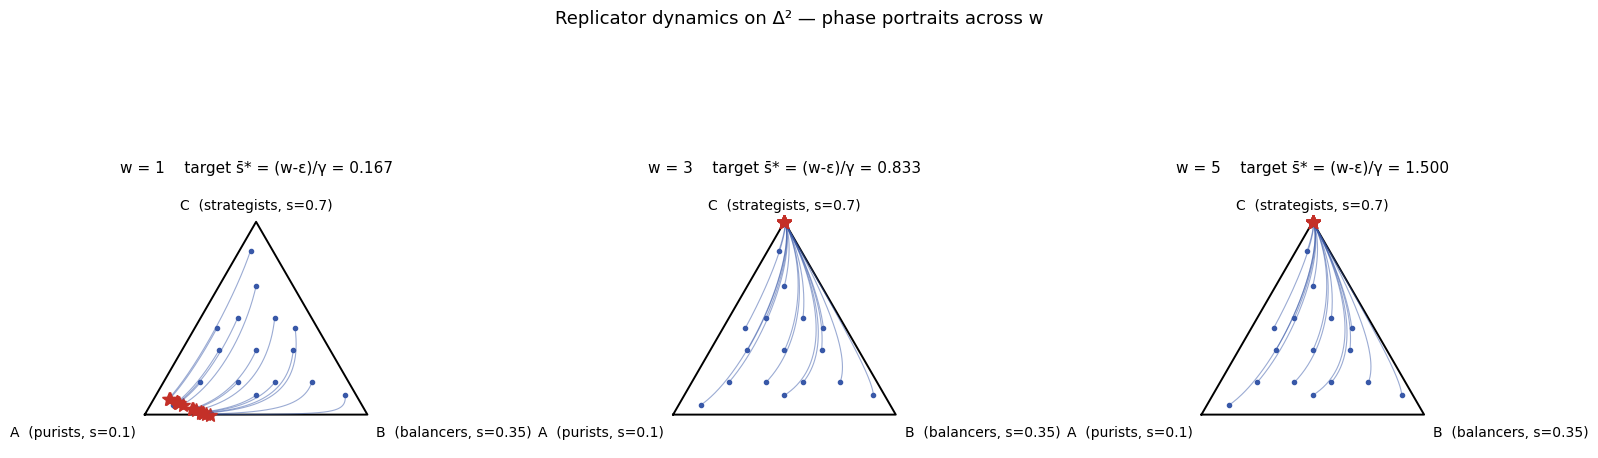

saved simplex figures


In [6]:
def grid_initial_conditions(n=6):
    pts = []
    for i in range(n + 1):
        for j in range(n + 1 - i):
            k = n - i - j
            if i > 0 and j > 0 and k > 0:
                pts.append(np.array([i, j, k]) / n)
    # Add near-vertex starts to expose vertex stability
    pts.extend([
        np.array([0.85, 0.10, 0.05]),
        np.array([0.05, 0.85, 0.10]),
        np.array([0.10, 0.05, 0.85]),
        np.array([0.45, 0.45, 0.10]),
        np.array([0.10, 0.45, 0.45]),
        np.array([0.45, 0.10, 0.45]),
    ])
    return pts

def plot_portrait(ax, w):
    draw_triangle(ax)
    for x0 in grid_initial_conditions(n=6):
        traj = simulate(w, x0, T=80.0, dt=0.04)
        xs, ys = to_xy(traj)
        ax.plot(xs, ys, "-", color="#3858a8", lw=0.8, alpha=0.5)
        ax.plot(xs[0], ys[0], "o", color="#3858a8", ms=3)
        ax.plot(xs[-1], ys[-1], "*", color="#c43028", ms=10)
    fp = interior_fp(w)
    if fp is not None:
        fx, fy = to_xy(fp)
        ax.plot(fx, fy, "X", color="black", ms=14, mew=2,
                label=f"interior s̄*={(w-EPS)/GAMMA:.3f}")
        ax.legend(loc="upper right", fontsize=9)
    s_target = (w - EPS) / GAMMA
    ax.set_title(f"w = {w}    target s̄* = (w-ε)/γ = {s_target:.3f}", fontsize=11)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, w in zip(axes, [1, 3, 5]):
    plot_portrait(ax, w)
fig.suptitle("Replicator dynamics on Δ² — phase portraits across w", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/simplex_panel.png", dpi=120, bbox_inches="tight")
plt.show()

# Save individual figures too.
for w in [1, 3, 5]:
    fig, ax = plt.subplots(figsize=(7, 6))
    plot_portrait(ax, w)
    plt.tight_layout()
    plt.savefig(f"{FIGDIR}/simplex_w{w}.png", dpi=120, bbox_inches="tight")
    plt.close(fig)
print("saved simplex figures")

## Empirical overlay — observed population state by career track

Cluster each respondent's `s` into one of three discrete types:
- A: `s < 0.2`
- B: `0.2 ≤ s < 0.5`
- C: `s ≥ 0.5`

Then compute the empirical mix $(x_A, x_B, x_C)$ per career track and plot on Δ².

In [7]:
df = pd.read_csv(DATA)

def cluster(s):
    if pd.isna(s): return np.nan
    if s < 0.2: return "A"
    if s < 0.5: return "B"
    return "C"

df["type"] = df["s"].apply(cluster)
type_by_track = (
    df.dropna(subset=["type"]).groupby("track")["type"]
      .value_counts(normalize=True).unstack().fillna(0)
      .reindex(columns=["A", "B", "C"], fill_value=0)
)
print("Empirical mix (x_A, x_B, x_C) by track:")
print(type_by_track.round(3))

Empirical mix (x_A, x_B, x_C) by track:
type                       A      B      C
track                                     
Finance/consulting     0.080  0.760  0.160
Government/ nonprofit  0.250  0.750  0.000
Graduate/ PhD program  0.333  0.667  0.000
Pre-med                0.333  0.667  0.000
Tech/engineering       0.222  0.556  0.222
Undecided/other        0.429  0.429  0.143


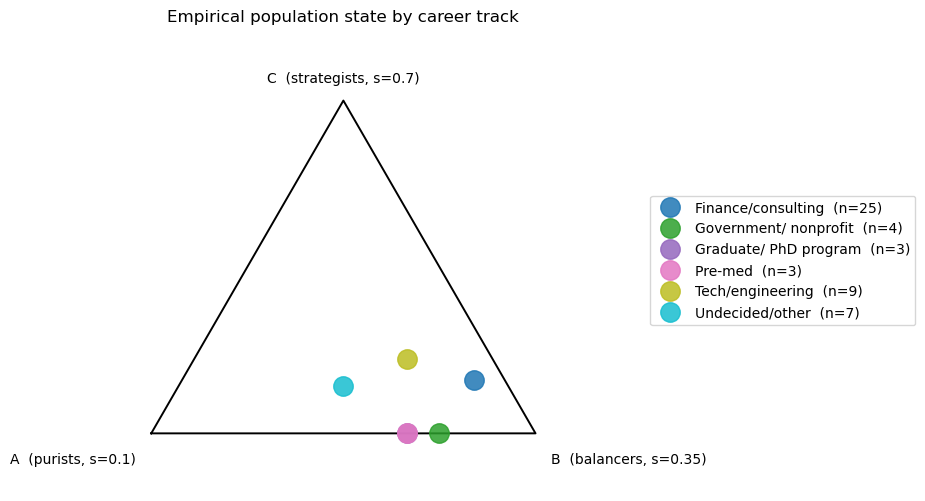

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
draw_triangle(ax)
colors = plt.cm.tab10(np.linspace(0, 1, len(type_by_track)))
for (track, state), color in zip(type_by_track.iterrows(), colors):
    state = state / state.sum()
    x, y = to_xy(state.values)
    n = (df["track"] == track).sum()
    ax.plot(x, y, "o", ms=14, color=color, alpha=0.85, label=f"{track}  (n={n})")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=10)
ax.set_title("Empirical population state by career track", fontsize=12)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/empirical_simplex.png", dpi=120, bbox_inches="tight")
plt.show()

## Policy counterfactual — eliminate enforced grade medians

The paper argues that eliminating enforced medians widens the layup vs. non-layup gap, effectively lowering $\gamma$. We model this as $\gamma \to \gamma/2$ and show the implied shift in $\bar s^\ast = (w-\varepsilon)/\gamma$ for each $w$.

In [9]:
rows = []
for w in [1, 2, 3, 4, 5]:
    s_base = (w - EPS) / GAMMA
    s_new = (w - EPS) / (GAMMA / 2)
    rows.append({
        "w": w,
        "s_target_baseline": round(min(max(s_base, 0), 1), 3),
        "s_target_after_policy": round(min(max(s_new, 0), 1), 3),
        "delta": round(min(max(s_new, 0), 1) - min(max(s_base, 0), 1), 3),
    })
policy = pd.DataFrame(rows)
print("Median-elimination counterfactual (γ → γ/2):")
print(policy.to_string(index=False))
print("\nInterpretation: lower γ lifts the target layup ratio for every w.")
print("Replicator dynamics under the new γ would drive the population toward higher s̄.")

Median-elimination counterfactual (γ → γ/2):
 w  s_target_baseline  s_target_after_policy  delta
 1              0.167                  0.333  0.167
 2              0.500                  1.000  0.500
 3              0.833                  1.000  0.167
 4              1.000                  1.000  0.000
 5              1.000                  1.000  0.000

Interpretation: lower γ lifts the target layup ratio for every w.
Replicator dynamics under the new γ would drive the population toward higher s̄.
